In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from deep_macrofin import PDEModel
from deep_macrofin import Comparator, OptimizerType, LossReductionMethod, set_seeds
from tqdm import tqdm
from torch.func import jacrev, hessian, vmap


In [2]:
class PDEModelCustomSample(PDEModel):
    def __init__(self, name, config, latex_var_mapping={}):
        super().__init__(name, config, latex_var_mapping)
        self.sample = self.sample_custom

        # self.OnTrainingStart += self.add_scheduler
        # self.OnTrainingStep += self.scheduler_step
        self.OnTrainingStep += self.change_batch_size


    def add_scheduler(self, **kwargs):
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.70, patience=1000, 
            threshold=1e-4, min_lr=1e-6
        )

    def scheduler_step(self, **kwargs):
        total_loss = 0
        for loss_label, loss in self.loss_val_dict.items():
            total_loss += self.loss_weight_dict[loss_label] * torch.where(loss.isnan(), 0.0, loss)
        self.scheduler.step(total_loss)
    
    def sample_simplex(self, epoch):
        eps = 0.05
        max_sum = 0.99
        alpha = torch.ones(len(self.state_variables), device=self.device)
        samples = torch.distributions.Dirichlet(alpha).sample((self.batch_size,))
        samples = eps + (max_sum - len(self.state_variables) * eps) * samples
        return samples[:, :-1]

    def sample_custom(self, epoch):
        xs = self.sample_simplex(epoch)
        alpha_p_max = self.variable_val_dict["alphap_max"]
        alpha_p_min = self.variable_val_dict["alphap_min"]
        alphap = torch.rand(xs.shape[0], 1, device=self.device) * (alpha_p_max - alpha_p_min) + alpha_p_min
        return torch.cat((xs, alphap), dim=1)

    def change_batch_size(self, **kwargs):
        if kwargs["epoch"] > 50000:
            self.config["batch_size"] = 500
            self.batch_size = 500
        else:
            self.config["batch_size"] = 200
            self.batch_size = 200

    def closure(self, SV):
        for i, sv_name in enumerate(self.state_variables):
            self.variable_val_dict[sv_name] = SV[:, i:i+1]
        self.variable_val_dict["SV"] = SV
        self.update_variables(SV)
        self.loss_fn()
        total_loss = 0
        for loss_label, loss in self.loss_val_dict.items():
            total_loss += self.loss_weight_dict[loss_label] * torch.where(loss.isnan(), 0.0, loss)

        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.optimizer.param_groups[0]['params'], max_norm=1.0)
        return total_loss

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "./models/aliens_3d"
# in the following, follow the sequence u, c, p
params = {
    "gamma": torch.tensor([1, 1, 1], device= device), # risk aversion
    "rho" : 0.05, # Discount rate
    "alpha_bar" : 1000.95, # lev. constrained ceiling
    "alphap_bar" : 0.0 , # Alpha passive agent 
    "theta" : 0.0, # Alpha drift
    "sig_alphap": torch.tensor([0, 0], device= device), # vol of passive demand share
    "nu": 0.5, # correlation
    "psi": 1.0, # intertemporal elasticity of substitution
    "mu": 0.022, # mean of the lognormal distribution of the asset return 
    "sigma": torch.tensor([0.035, 0.00], device=device), # fundamental vol
    "kappa": 0.00, # death intensity
    "omega": torch.tensor([0.25, 0.25, 0.50], device= device), # mass of each agent
    "alphap_min": 0.0, # minimum alpha for passive agent
    "alphap_max": 0.0, # maximum alpha for passive
}

In [4]:
def compute_y(SV, compute_xiu, compute_xic, compute_xip):
    xu = SV[:,0:1]
    xc = SV[:,1:2]
    xp = 1 - xu - xc
    xiu = compute_xiu(SV)
    xic = compute_xic(SV)
    xip = compute_xip(SV)
    y = xu*xiu+xc*xic+xp*xip
    return y

def compute_dydx(SV, compute_xiu, compute_xic, compute_xip, compute_y):
    dy_dx = vmap(jacrev(lambda sv: compute_y(sv.unsqueeze(0), compute_xiu, compute_xic, compute_xip).squeeze(0)))(SV)
    return dy_dx

def compute_d2ydx2(SV, compute_xiu, compute_xic, compute_xip, compute_y):
    d2y_dx2 = vmap(hessian(lambda sv: compute_y(sv.unsqueeze(0), compute_xiu, compute_xic, compute_xip).squeeze(0)))(SV)
    return d2y_dx2

def merge_xi(xiu, xic, xip):
    # xiu is of shape (B, 1)
    return torch.cat([xiu, xic, xip], dim=1)

def merge_xi_jac(xiu_Jac, xic_Jac, xip_Jac):
    # xiu_Jac is of shape (B, 1, n_state)
    return torch.cat([xiu_Jac, xic_Jac, xip_Jac], dim=1)

def merge_xi_Hess(xiu_Hess, xic_Hess, xip_Hess):
    # xiu_Hess is of shape (B, 1, n_state, n_state)
    return torch.cat([xiu_Hess, xic_Hess, xip_Hess], dim=1)

def merge_sigy(sigy1, sigy2):
    # sigy1 is of shape (B, 1)
    return torch.cat([sigy1, sigy2], dim=1)

def compute_muP(muy, sigy, sigR, sigma, mu):
    # mup = -muy + sum(sigy * (sigy - sigma.T))
    # muP = mup + mu + sum(sigR_norm^2 - sigma.T * sigR)
    sigma_T = sigma.reshape(1, 2)  # (1, 2) to match sigmaAll.T shape
    sigR_norm_sq = torch.sum(sigR**2, dim=1, keepdim=True)  # (B, 1)
    mup = -muy + torch.sum(sigy * (sigy - sigma_T), dim=1, keepdim=True)  # (B, 1)
    muP = mup + mu + torch.sum(sigR_norm_sq - sigma_T * sigR, dim=1, keepdim=True)  # (B, 1)
    return muP

def compute_sigx(xc, alphap, nu, sig_alphap, alphaState, sigR):
    sig_state = (alphaState.unsqueeze(2) - 1) * sigR.unsqueeze(1)  # [200, 2, 2]
    sig_alphap1 = sig_alphap[0]
    sigalphap_W = torch.stack(
        (torch.ones_like(xc) * (sig_alphap1 * nu),
        torch.ones_like(xc) * (sig_alphap1 * (1 - nu**2)**0.5)),
        dim=2
    ) 

    return torch.cat((sig_state,sigalphap_W/(alphap+1e-6).unsqueeze(-1)),dim=1)

def compute_mux(r, eta, alphaAll, sigR_norm, xi, muP, kappa, omega, xAll, mu_alphap):
    mu_xstate = r + eta * alphaAll * sigR_norm - xi -muP + (1-alphaAll) * sigR_norm**2  + kappa * (omega-xAll)/xAll
    mux = torch.cat((mu_xstate[:,0:2], mu_alphap), dim=1)
    return mux

def compute_a_mat(xsigx):
    return torch.einsum("bij,bkj->bik", xsigx, xsigx)

def compute_muxi(xi, xi_Jac, xi_Hess, mux, x, a_mat):
    muxiAll_1 = torch.einsum("bij,bj->bi", xi_Jac, mux * x) / xi
    muxiAll_2 = 0.5 * torch.einsum("bijk,bkj->bi", xi_Hess, a_mat) / xi
    return muxiAll_1 + muxiAll_2

def compute_mu_y(y, dy_dx, d2y_dx2, a_mat, mux, x):
    mu_y_1 = torch.einsum("bij,bj->bi", dy_dx, mux * x) / y
    mu_y_2 = 0.5 * torch.einsum("bijk,bkj->bi", d2y_dx2, a_mat) / y
    return mu_y_1 + mu_y_2

def compute_varsigma(gamma, muxi, sigxi, sigR, psi):
    gamma = gamma.reshape(1, 3)
    if psi == 1.0:
        varsigma = torch.zeros_like(muxi)
    else:
        varsigma = (1-gamma)/(1-psi) * torch.sum(sigxi.transpose(1,2)*sigR.unsqueeze(-1),axis=1)/torch.sum(sigR**2, axis=1,keepdim=True)
    return varsigma

def compute_hjb(gamma, muxi, sigxi, sigR, psi, r, eta, alphaAll, sigR_norm, xi, rho):
    gamma = gamma.reshape(1, 3)
    if psi == 1.0:
        hjb = rho + muxi - xi + (1-gamma) * torch.sum((sigxi.transpose(1,2)*sigR.unsqueeze(-1)),axis=1) * alphaAll 
    else:
        hjb = (
            rho * psi + (1 - psi) * (r + eta * alphaAll * sigR_norm - gamma/2 * (alphaAll * sigR_norm)**2) + muxi 
            + (1-gamma) * torch.sum((sigxi.transpose(1,2)*sigR.unsqueeze(-1)),axis=1) * alphaAll 
            + (psi - gamma)/(1-psi) *torch.sum(sigxi**2,axis=2)/2 - xi
        )
    hjb = hjb / rho
    hjb_err = torch.mean(hjb**2,dim=0).sum()
    return hjb_err

def compute_foc_u(pi, gamma, sigR_norm, varsigma):
    gamma_u = gamma[0]
    return pi/(gamma_u * sigR_norm**2) + varsigma[:,0:1]

def compute_foc_c(pi, gamma, sigR_norm, varsigma, alpha_bar):
    gamma_c = gamma[1]
    compare1 = pi/(gamma_c * sigR_norm**2) + varsigma[:,1:2]
    compare2 = (alpha_bar/sigR_norm)
    return torch.min(compare1, compare2)

def compute_consistency(sig_alphap, nu, sigma, dy_dx, alphaState, y, sigy):
    sig_alphap1 = sig_alphap[0]
    # sig_matrix rows correspond to [alphau, alphac, alphap] order
    # alphaState is [alphau, alphac], so first two rows are for u and c
    sig_matrix = torch.tensor([
        [sigma[0], sigma[1]],  # row 0: for alphau (u)
        [sigma[0], sigma[1]],  # row 1: for alphac (c)
        [sig_alphap1 * nu, sig_alphap1 * (1 - nu**2)**0.5]  # row 2: for alphap (p)
    ], dtype=torch.float32, device=device)
    # alphaState is [alphau, alphac], so cat gives [alphau-1, alphac-1, 1]
    # This matches sig_matrix rows [u, c, p]
    num = torch.einsum("bij,bj,jk->bik",dy_dx,torch.cat((alphaState-1, torch.ones_like(y)), dim=1),sig_matrix).squeeze(1)
    # dy_dx[:, 0, :2] is [dy/dxu, dy/dxc] and alphaState is [alphau, alphac], so order matches
    den = y + torch.einsum("bj,bj->b",dy_dx[:, 0, :2], alphaState - 1).unsqueeze(-1)
    consistency1 = sigy[:, 0:1] - num[:, 0:1]/den
    consistency2 = sigy[:, 1:2] - num[:, 1:2]/den
    return torch.mean(consistency1 ** 2) + torch.mean(consistency2**2)

def get_model(model_path: str, params: dict, model_size: list[int]):
    set_seeds(42)
    model = PDEModelCustomSample("aliens_3d", config={"batch_size": 200, "num_epochs": 100000, "optimizer_type": OptimizerType.Adam, "lr": 0.0005})
    model.set_state(["xu", "xc", "alphap"], 
        {"xu": [0, 1], "xc": [0, 1], "alphap": [params["alphap_min"], params["alphap_max"]]}
    )
    model.add_params(params)
    model.register_functions([
        compute_y, compute_dydx, compute_d2ydx2,
        merge_xi, merge_xi_jac, merge_xi_Hess, merge_sigy,
        compute_muP, 
        compute_sigx,
        compute_mux,
        compute_a_mat,
        compute_muxi,
        compute_mu_y,
        compute_varsigma,
        compute_hjb,
        compute_foc_u,
        compute_foc_c,
        compute_consistency
    ])
    model.add_agent("xiu", config={"hidden_units": [256]*4, "batch_jac_hes": True, "positive": True})
    model.add_agent("xic", config={"hidden_units": [256]*4, "batch_jac_hes": True, "positive": True})
    model.add_agent("xip", config={"hidden_units": [256]*4, "batch_jac_hes": True, "positive": True})
    model.add_endog("pi", config={"hidden_units": [256]*4, "derivative_order": 0})
    model.add_endog("r", config={"hidden_units": [256]*4, "derivative_order": 0})
    model.add_endog("muy", config={"hidden_units": [256]*4, "derivative_order": 0})
    model.add_endog("sigy1", config={"hidden_units": [256]*4, "derivative_order": 0})
    model.add_endog("sigy2", config={"hidden_units": [256]*4, "derivative_order": 0})
    model.add_endog("alphac", config={"hidden_units": [256]*4, "derivative_order": 0})

    model.add_equations([
        "xp=1-xu-xc", # (B, 1)
        "xAll=torch.cat((xu,xc,xp),dim=1)", # (B, 3)
        "y=xu*xiu+xc*xic+xp*xip", # (B, 1)
        "dy_dx=compute_dydx(SV, compute_xiu, compute_xic, compute_xip, compute_y)", # (B, 1, 3)
        "d2y_dx2=compute_d2ydx2(SV, compute_xiu, compute_xic, compute_xip, compute_y)", # (B, 1, 3, 3)
        "xi=merge_xi(xiu, xic, xip)",
        "xi_Jac=merge_xi_jac(xiu_Jac, xic_Jac, xip_Jac)",
        "xi_Hess=merge_xi_Hess(xiu_Hess, xic_Hess, xip_Hess)",
        "sigy=merge_sigy(sigy1, sigy2)",
        "alphau=(1-xc*alphac-xp*alphap)/(xu+1e-6)", # (B, 1)
        "alphaState=torch.cat((alphau,alphac),dim=1)", # (B, 2)
        "alphaAll=torch.cat((alphau,alphac,alphap),dim=1)", # (B, 3)
        "sigR=sigma.reshape(1,2)-sigy", # (B, 2)
        "sigR_norm=torch.sum(sigR**2, axis=1,keepdim=True)**0.5", # (B, 1)
        "muP=compute_muP(muy,sigy,sigR,sigma,mu)", # (B, 1)
        "eta=pi/sigR_norm", # (B, 1)
        "sigx=compute_sigx(xc,alphap,nu,sig_alphap,alphaState,sigR)", # (B, 3, 2)
        "xsigx=sigx*SV.unsqueeze(-1)", # (B, 3, 2)
        "a_mat=compute_a_mat(xsigx)", # (B, 3, 3)
        "mu_alphap=theta*(alphap_bar-alphap)/(alphap+1e-6)", # (B, 1)
        "sigxi=torch.bmm(xi_Jac, xsigx)", # (B, 3, 2)
        "mux=compute_mux(r,eta,alphaAll,sigR_norm,xi,muP,kappa,omega,xAll,mu_alphap)", # (B, 3)
        "muxi=compute_muxi(xi, xi_Jac, xi_Hess, mux, SV, a_mat)", # (B, 3)
        "mu_y=compute_mu_y(y, dy_dx, d2y_dx2, a_mat, mux, SV)", # (B, 1)
        "varsigma=compute_varsigma(gamma, muxi, sigxi, sigR, psi)", # (B, 3)
        "hjb=compute_hjb(gamma, muxi, sigxi, sigR, psi, r, eta, alphaAll, sigR_norm, xi, rho)", # (B, 1)
    ])

    model.add_endog_equation("alphau=compute_foc_u(pi, gamma, sigR_norm, varsigma)")
    model.add_endog_equation("alphac=compute_foc_c(pi, gamma, sigR_norm, varsigma, alpha_bar)")
    model.add_endog_equation("(muP+y-r-pi)/rho=0")
    model.add_endog_equation("(muy-mu_y)/(y+1e-6)=0")
    model.add_hjb_equation("hjb", loss_reduction=LossReductionMethod.NONE)
    model.add_hjb_equation("compute_consistency(sig_alphap, nu, sigma, dy_dx, alphaState, y, sigy)",loss_reduction=LossReductionMethod.NONE)


    if not os.path.exists(f"{model_path}/model.pt"):
        model.train_model(model_path, "model.pt", True)
    model.load_model(torch.load(f"{model_path}/model_best.pt", weights_only=False))
    return model

In [5]:
model_path = f"./models/basak_cuoco"
model = get_model(model_path, params, [10]*8)

Model loaded


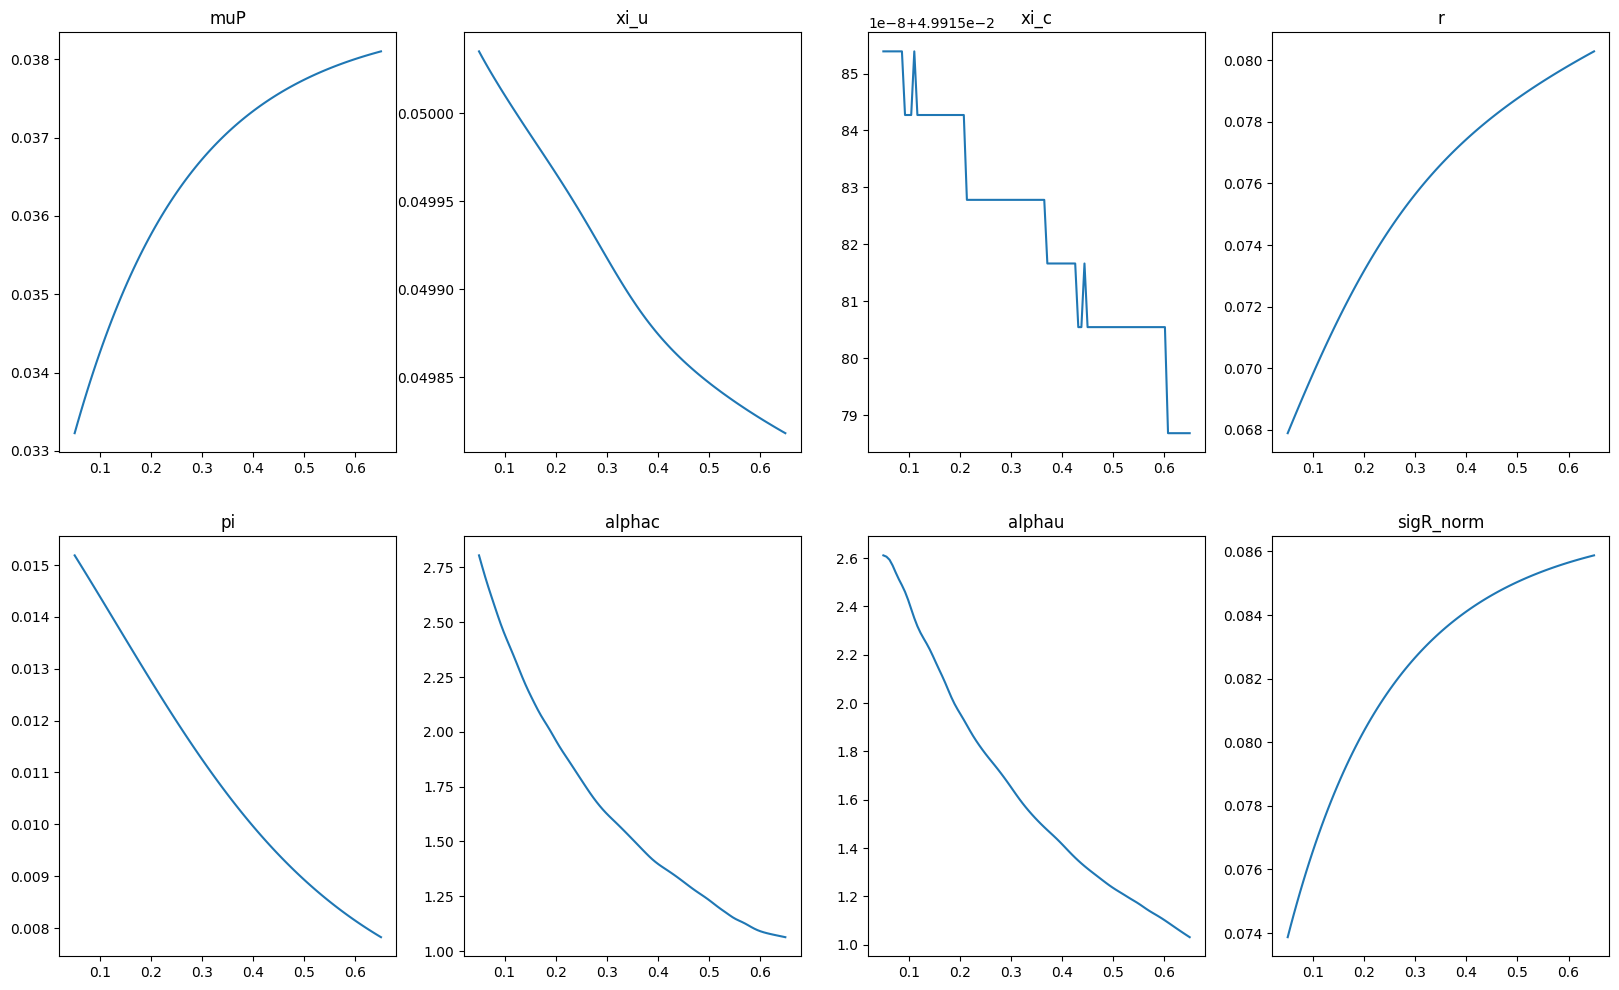

In [6]:
SV = torch.zeros(100, 3, device=model.device)
SV[:, 0] = torch.linspace(0.05, 0.65, 100, device=model.device) # xu
SV[:, 1] = 0.31 # xc
SV.requires_grad_(True)
x_plot = SV[:, 0].detach().cpu().numpy().reshape(-1)
for i, sv_name in enumerate(model.state_variables):
    model.variable_val_dict[sv_name] = SV[:, i:i+1]
model.variable_val_dict["SV"] = SV
model.update_variables(SV)

muP = model.variable_val_dict["muP"].detach().cpu().numpy().reshape(-1)
xi = model.variable_val_dict["xi"]
xiu = xi[:, 0:1].detach().cpu().numpy().reshape(-1)
xic = xi[:, 1:2].detach().cpu().numpy().reshape(-1)
r = model.variable_val_dict["r"].detach().cpu().numpy().reshape(-1)
pi = model.variable_val_dict["pi"].detach().cpu().numpy().reshape(-1)
alphac = model.variable_val_dict["alphac"].detach().cpu().numpy().reshape(-1)
alphau = model.variable_val_dict["alphau"].detach().cpu().numpy().reshape(-1)
sigR_norm = model.variable_val_dict["sigR_norm"].detach().cpu().numpy().reshape(-1)

fig, ax = plt.subplots(2, 4, figsize=(20, 12))
ax[0][0].plot(x_plot, muP)
ax[0][0].set_title("muP")
ax[0][1].plot(x_plot, xiu)
ax[0][1].set_title("xi_u")
ax[0][2].plot(x_plot, xic)
ax[0][2].set_title("xi_c")
ax[0][3].plot(x_plot, r)
ax[0][3].set_title("r")
ax[1][0].plot(x_plot, pi)
ax[1][0].set_title("pi")
ax[1][1].plot(x_plot, alphac)
ax[1][1].set_title("alphac")
ax[1][2].plot(x_plot, alphau)
ax[1][2].set_title("alphau")
ax[1][3].plot(x_plot, sigR_norm)
ax[1][3].set_title("sigR_norm")
plt.show()

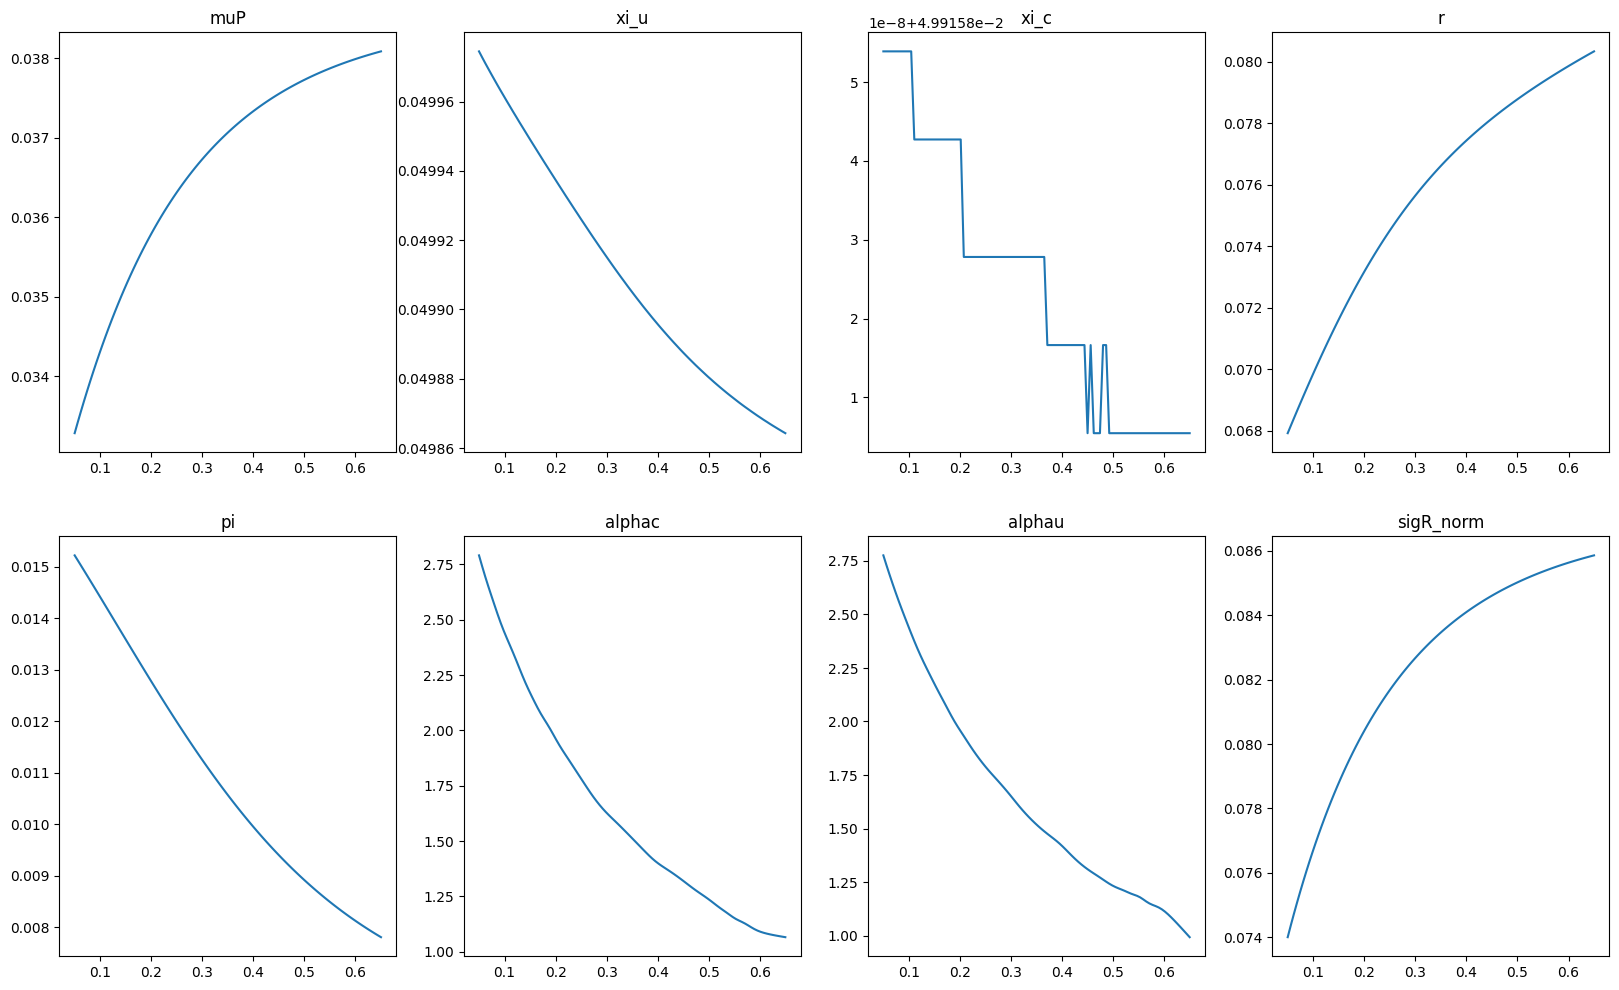

In [7]:
SV = torch.zeros(100, 3, device=model.device)
SV[:, 0] = 0.31 # xu
SV[:, 1] = torch.linspace(0.05, 0.65, 100, device=model.device) # xc
SV.requires_grad_(True)
x_plot = SV[:, 1].detach().cpu().numpy().reshape(-1)
for i, sv_name in enumerate(model.state_variables):
    model.variable_val_dict[sv_name] = SV[:, i:i+1]
model.variable_val_dict["SV"] = SV
model.update_variables(SV)

muP = model.variable_val_dict["muP"].detach().cpu().numpy().reshape(-1)
xi = model.variable_val_dict["xi"]
xiu = xi[:, 0:1].detach().cpu().numpy().reshape(-1)
xic = xi[:, 1:2].detach().cpu().numpy().reshape(-1)
r = model.variable_val_dict["r"].detach().cpu().numpy().reshape(-1)
pi = model.variable_val_dict["pi"].detach().cpu().numpy().reshape(-1)
alphac = model.variable_val_dict["alphac"].detach().cpu().numpy().reshape(-1)
alphau = model.variable_val_dict["alphau"].detach().cpu().numpy().reshape(-1)
sigR_norm = model.variable_val_dict["sigR_norm"].detach().cpu().numpy().reshape(-1)

fig, ax = plt.subplots(2, 4, figsize=(20, 12))
ax[0][0].plot(x_plot, muP)
ax[0][0].set_title("muP")
ax[0][1].plot(x_plot, xiu)
ax[0][1].set_title("xi_u")
ax[0][2].plot(x_plot, xic)
ax[0][2].set_title("xi_c")
ax[0][3].plot(x_plot, r)
ax[0][3].set_title("r")
ax[1][0].plot(x_plot, pi)
ax[1][0].set_title("pi")
ax[1][1].plot(x_plot, alphac)
ax[1][1].set_title("alphac")
ax[1][2].plot(x_plot, alphau)
ax[1][2].set_title("alphau")
ax[1][3].plot(x_plot, sigR_norm)
ax[1][3].set_title("sigR_norm")
plt.show()